Lecture: AI I - Basics 

Previous:
[**Chapter 4.3: Evaluation with scikit-learn**](../03_evaluation.ipynb)

---

# Chapter 4.4: Gradient Boosting with XGBoost and LightGBM

- [What is Gradient Boosting?](#what-is-gradient-boosting)
- [XGBoost](#xgboost)
- [LightGBM](#lightgbm)
- [The Most Important Hyperparameters](#the-most-important-hyperparameters)
- [Nested Cross-Validation with Optuna](#nested-cross-validation-with-optuna)
- [Quantile Regression](#quantile-regression)

In [Chapter 4.2](./02_machine_learning.ipynb) we saw the Random Forest: many decision trees are trained **independently** on random subsets of the data, and their predictions are averaged. This is called *bagging*.

In this notebook we look at the second big family of tree ensembles: **boosting**. Here the trees are *not* independent. Each new tree is trained to fix the mistakes of the trees before it. Gradient boosting is, for tabular data (rows and columns, like a spreadsheet or a database table), still the method that wins most competitions and most internal benchmarks — usually ahead of neural networks.

We will use the two most common implementations:

- [**XGBoost**](https://xgboost.readthedocs.io/en/stable/) — the classic, very robust, huge feature set
- [**LightGBM**](https://lightgbm.readthedocs.io/en/stable/) — from Microsoft, usually faster on large datasets

Both are *not* part of scikit-learn, but both provide a scikit-learn compatible API (`fit()`, `predict()`, usable in `Pipeline` and in `cross_val_score`). So everything you learned in the previous notebooks still applies.

## What is Gradient Boosting?

The idea is short enough to fit into three sentences:

1. Start with a very simple prediction (e.g. the mean of the target).
2. Look at the **errors** (residuals) that this prediction makes, and train a small decision tree that predicts *these errors*.
3. Add a fraction of this tree to your current prediction and repeat, a few hundred times.

Formally, the model after $M$ steps is a sum of trees:

$$F_M(x) = F_0(x) + \eta \cdot h_1(x) + \eta \cdot h_2(x) + \dots + \eta \cdot h_M(x)$$

where $h_m$ is the $m$-th tree and $\eta$ is the **learning rate** (typically 0.01–0.3). The learning rate shrinks each step so that no single tree can dominate — a form of regularization.

Why the name *gradient* boosting? Because the residual we fit in step 2 is exactly the negative gradient of the loss function with respect to the current prediction. For the squared error loss this gradient *is* the residual $y - F(x)$; for other losses (log loss for classification, pinball loss for quantiles, see below) it is something else. That is the only place where the maths matters: **change the loss function, and the same algorithm solves a different problem.** We will use exactly this trick later for quantile regression.

__Bagging vs. Boosting:__

| | Random Forest (bagging) | Gradient Boosting |
|---|---|---|
| Trees are trained | in parallel, independently | sequentially, each on the errors of the previous |
| Individual trees are | deep, low bias, high variance | shallow ("weak learners"), depth 3–8 |
| Adding more trees | never really hurts | **can overfit** |
| Main tuning knob | number of trees | learning rate × number of trees |
| Parallelizable | trivially | only within a tree |

__Advantages:__
- Usually the best accuracy on tabular data
- Handles mixed feature types, missing values and unscaled features without preprocessing
- Built-in feature importances

__Disadvantages:__
- Many hyperparameters, and it *is* sensitive to them
- Can overfit if trained too long (unlike a Random Forest)
- Sequential training, so less parallel than bagging
- Harder to interpret than a single tree

## XGBoost

[XGBoost](https://xgboost.readthedocs.io/en/stable/) ("eXtreme Gradient Boosting") provides the classes `XGBClassifier` and `XGBRegressor` which behave like scikit-learn estimators.

We use the breast cancer dataset (a binary classification toy dataset, 569 samples, 30 numerical features).

In [1]:
import xgboost as xgb

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = datasets.load_breast_cancer(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = xgb.XGBClassifier(
    n_estimators=300,        # number of trees
    learning_rate=0.05,      # eta
    max_depth=3,             # depth of each tree
    subsample=0.8,           # use 80% of the rows per tree
    colsample_bytree=0.8,    # use 80% of the features per tree
    eval_metric="logloss",
    random_state=42,
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"accuracy: {accuracy_score(y_test, y_pred):.3f}")

accuracy: 0.972


Just like in scikit-learn, `predict_proba()` gives the class probabilities:

In [2]:
clf.predict_proba(X_test)[:5]

array([[1.9314885e-03, 9.9806851e-01],
       [9.9961817e-01, 3.8182188e-04],
       [4.9749136e-01, 5.0250864e-01],
       [2.9023588e-02, 9.7097641e-01],
       [1.2098986e-01, 8.7901014e-01]], dtype=float32)

### Early stopping

The number of trees is the one parameter you do *not* have to guess. Give XGBoost a validation set and let it stop as soon as the validation loss stops improving.

In [3]:
clf_es = xgb.XGBClassifier(
    n_estimators=2000,           # deliberately far too many
    learning_rate=0.05,
    max_depth=3,
    eval_metric="logloss",
    early_stopping_rounds=20,    # stop after 20 rounds without improvement
    random_state=42,
)
clf_es.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

print(f"best iteration: {clf_es.best_iteration}")
print(f"accuracy: {accuracy_score(y_test, clf_es.predict(X_test)):.3f}")

best iteration: 173
accuracy: 0.958


> We use the test set as the validation set here only to keep the example short. That is **data leakage** — the number of trees is then chosen using the test data, and your test score is optimistic. In a real project use a separate validation split (see the nested CV below).

### Learning curves and feature importance

/tmp/ipykernel_9575/3120846447.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


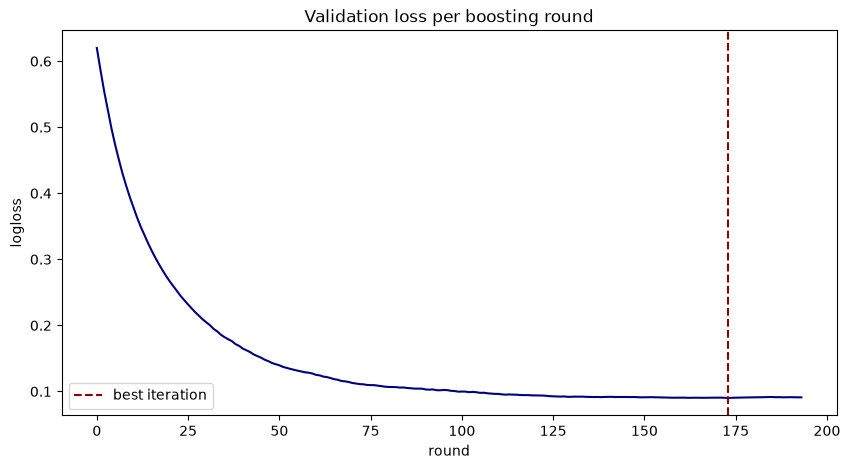

In [4]:
from matplotlib import pyplot as plt

results = clf_es.evals_result()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results["validation_0"]["logloss"], color="navy")
ax.axvline(clf_es.best_iteration, color="darkred", ls="--", label="best iteration")
ax.set(title="Validation loss per boosting round", xlabel="round", ylabel="logloss")
ax.legend()
fig.show()

/tmp/ipykernel_9575/1865996296.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


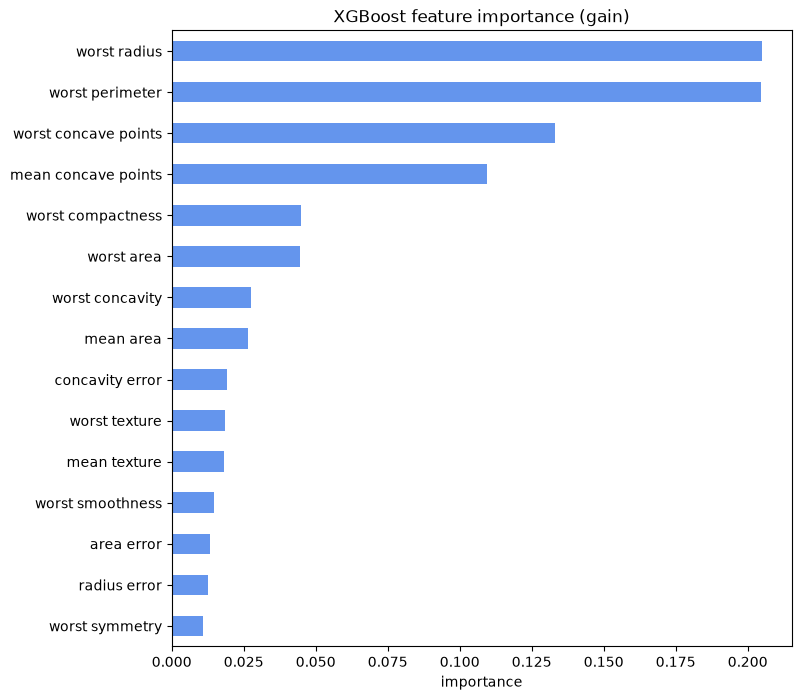

In [5]:
import pandas as pd

importance = pd.Series(clf.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
importance.tail(15).plot.barh(ax=ax, color="cornflowerblue")
ax.set(title="XGBoost feature importance (gain)", xlabel="importance")
fig.show()

> These importances tell you what the *model* used, not what *causes* the target. Correlated features share (and thereby dilute) their importance. For a more reliable analysis use [permutation importance](https://scikit-learn.org/stable/modules/permutation_importance.html) or SHAP values.

## LightGBM

[LightGBM](https://lightgbm.readthedocs.io/en/stable/) solves the same problem, with two notable differences:

- **Leaf-wise growth:** XGBoost grows a tree level by level (all nodes of a depth are split). LightGBM always splits the single leaf that promises the largest loss reduction. This gives better accuracy per tree, but the trees become unbalanced, so LightGBM is controlled with `num_leaves` rather than `max_depth`.
- **Histogram binning:** continuous features are bucketed into (by default 255) bins before training. This makes split finding dramatically faster on large datasets.

The API is the same:

In [6]:
import lightgbm as lgb

lgb_clf = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,            # instead of max_depth; must be < 2**max_depth
    min_child_samples=20,     # minimum number of samples in a leaf
    subsample=0.8,
    colsample_bytree=0.8,
    verbose=-1,               # LightGBM is chatty by default
    random_state=42,
)
lgb_clf.fit(X_train, y_train)

print(f"accuracy: {accuracy_score(y_test, lgb_clf.predict(X_test)):.3f}")

accuracy: 0.965


Early stopping works via callbacks:

In [7]:
lgb_es = lgb.LGBMClassifier(n_estimators=2000, learning_rate=0.05, num_leaves=15,
                            verbose=-1, random_state=42)
lgb_es.fit(
    X_train, y_train,
    eval_X=X_test, eval_y=y_test,          # older versions: eval_set=[(X_test, y_test)]
    eval_metric="binary_logloss",
    callbacks=[lgb.early_stopping(20, verbose=False)],
)

print(f"best iteration: {lgb_es.best_iteration_}")
print(f"accuracy: {accuracy_score(y_test, lgb_es.predict(X_test)):.3f}")

best iteration: 83
accuracy: 0.965


__When to use which?__

| | XGBoost | LightGBM |
|---|---|---|
| Small data (< ~10k rows) | very robust, good default | can overfit, lower `num_leaves` |
| Large data | slower | usually much faster |
| Categorical features | needs encoding (or `enable_categorical=True`) | native support via `pandas` `category` dtype |
| Main depth parameter | `max_depth` | `num_leaves` |

In practice: try both, they are usually within a percent of each other. A third option worth knowing is [CatBoost](https://catboost.ai/), which is especially strong with many categorical features. Scikit-learn itself also ships [`HistGradientBoostingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html), a LightGBM-like implementation with no extra dependency.

## The Most Important Hyperparameters

You do not need to tune all of them. These are the ones that matter, roughly in order of importance:

| Parameter (XGB / LGBM) | Meaning | Typical range |
|---|---|---|
| `learning_rate` | how much each tree contributes | 0.01 – 0.3 |
| `n_estimators` | number of trees | 100 – 2000 (or early stopping) |
| `max_depth` / `num_leaves` | complexity of a single tree | 2 – 8 / 15 – 63 |
| `min_child_weight` / `min_child_samples` | minimum "mass" in a leaf | 1 – 20 |
| `subsample` | fraction of rows per tree | 0.5 – 1.0 |
| `colsample_bytree` | fraction of features per tree | 0.5 – 1.0 |
| `reg_lambda`, `reg_alpha` | L2 / L1 penalty on leaf weights | 1e-3 – 20 (log scale) |
| `gamma` / `min_split_gain` | minimum loss reduction for a split | 0 – 5 |

The first two are coupled: a smaller learning rate needs more trees. A common workflow is to fix the learning rate at 0.05, use early stopping for the number of trees, and tune the rest.

## Nested Cross-Validation with Optuna

Now we combine three things from the previous notebooks: cross-validation, hyperparameter tuning, and an honest estimate of the generalization error.

__The problem:__ if you tune hyperparameters and then report the score of the best configuration on the same data you tuned on, that score is optimistic. You have effectively fitted the hyperparameters to your validation set.

__The solution: nested cross-validation.__

- The **outer loop** splits the data into folds. One fold at a time is held out as a test set — it is *never* seen during tuning.
- The **inner loop** runs on the remaining data only, and does another cross-validation to search for the best hyperparameters.
- The best model of the inner loop is evaluated once on the outer test fold.

So the outer scores answer *"how well does my whole pipeline, including tuning, generalize?"*, while the inner loop answers *"which hyperparameters should I use?"*.

<img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_nested_cross_validation_iris_001.png" width="600">

We use [Optuna](https://optuna.readthedocs.io/en/stable/) as the optimizer. Compared to `GridSearchCV` from Chapter 4.3 it:

- samples parameter values from ranges (`suggest_float`, `suggest_int`) instead of a fixed grid,
- uses a **TPE sampler**, which learns from previous trials which regions are promising (Bayesian optimization),
- can **prune** hopeless trials early.

The data is the iris toy dataset, and we stratify on the target so every fold has the same class distribution.

In [8]:
import optuna
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

optuna.logging.set_verbosity(optuna.logging.WARNING)  # otherwise one log line per trial

X, y = datasets.load_iris(return_X_y=True, as_frame=True)
print(X.shape, y.value_counts().to_dict())

(150, 4) {0: 50, 1: 50, 2: 50}


### The inner loop: search for hyperparameters

In [9]:
def inner_cv(X_train, y_train, n_inner=3, n_trials=25, seed=42):
    """Tune LightGBM on the training part of an outer fold and return the fitted model."""

    def objective(trial):
        params = {
            # searched parameters
            "n_estimators": trial.suggest_int("n_estimators", 50, 300, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 2, 31),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            # fixed parameters
            "objective": "multiclass",
            "num_class": 3,
            "random_state": seed,
            "verbose": -1,
        }

        inner = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=seed)
        scores = []
        for fold, (train_idx, valid_idx) in enumerate(inner.split(X_train, y_train)):
            model = lgb.LGBMClassifier(**params)
            model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])

            pred = model.predict(X_train.iloc[valid_idx])
            scores.append(accuracy_score(y_train.iloc[valid_idx], pred))

            # let Optuna abort clearly hopeless trials early
            trial.report(np.mean(scores), step=fold)
            if trial.should_prune():
                raise optuna.TrialPruned()

        return float(np.mean(scores))

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=1),
    )
    study.optimize(objective, n_trials=n_trials)

    best_params = {
        **study.best_params,
        "objective": "multiclass",
        "num_class": 3,
        "random_state": seed,
        "verbose": -1,
    }

    # refit on the complete training part of this outer fold
    model = lgb.LGBMClassifier(**best_params).fit(X_train, y_train)
    return model, best_params, study.best_value

### The outer loop: honest evaluation

In [10]:
def nested_cv(X, y, n_outer=5, n_inner=3, n_trials=25, seed=42):
    outer = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=seed)

    results = []
    for i, (train_idx, test_idx) in enumerate(outer.split(X, y)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

        model, best_params, inner_score = inner_cv(
            X_train, y_train, n_inner=n_inner, n_trials=n_trials, seed=seed
        )

        outer_score = accuracy_score(y_test, model.predict(X_test))
        print(f"fold {i + 1}: inner = {inner_score:.3f} | outer = {outer_score:.3f}")

        results.append({"fold": i + 1, "inner_score": inner_score,
                        "outer_score": outer_score, **best_params})

    return pd.DataFrame(results)

results = nested_cv(X, y)

fold 1: inner = 0.942 | outer = 0.967
fold 2: inner = 0.958 | outer = 1.000
fold 3: inner = 0.975 | outer = 0.900
fold 4: inner = 0.950 | outer = 1.000
fold 5: inner = 0.967 | outer = 0.900


In [11]:
results[["fold", "inner_score", "outer_score", "n_estimators", "num_leaves", "learning_rate"]]

,fold,inner_score,outer_score,n_estimators,num_leaves,learning_rate
0,1,0.941667,0.966667,200,3,0.017860
1,2,0.958333,1.000000,50,20,0.190304
2,3,0.975000,0.900000,150,17,0.289969
3,4,0.950000,1.000000,50,20,0.190304
4,5,0.966667,0.900000,100,22,0.013940


In [12]:
print(f"generalization estimate: {results.outer_score.mean():.3f} "
      f"± {results.outer_score.std():.3f}")

generalization estimate: 0.953 ± 0.051


Two things are worth pointing out:

1. The **inner scores are systematically different from the outer scores** — that is exactly the optimism we wanted to remove. Reporting the inner score as your model quality would be wrong.
2. **Every fold selects different hyperparameters** (look at `n_estimators` and `num_leaves` in the table). This is normal, especially on a small dataset. It also means: the result of nested CV is *a performance estimate*, not *a model*. To ship a model, run the tuning once more on the complete dataset.

> **Grouped data.** If your rows are not independent — several measurements per patient, several images per site, several rows per customer — a random split leaks information between train and test. Use [`GroupKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html) or [`StratifiedGroupKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html) and pass a `groups` array, so that all rows of a group land in the same fold. The code above changes only in the `.split(X, y, groups)` calls.

## Quantile Regression

So far, our regression models predicted a single number: the conditional **mean** $E[y \mid x]$. But "the predicted delivery time is 5 days" is much less useful than "the delivery takes between 3 and 9 days in 80% of cases". Quantile regression gives you the second kind of answer.

Instead of the squared error we minimize the **pinball loss** (or quantile loss) for a quantile $q \in (0, 1)$:

$$L_q(y, \hat{y}) = \begin{cases} q \cdot (y - \hat{y}) & \text{if } y \ge \hat{y} \\ (1 - q) \cdot (\hat{y} - y) & \text{if } y < \hat{y} \end{cases}$$

The trick is the asymmetry. For $q = 0.9$, being *too low* is penalized nine times more than being *too high*, so the model that minimizes this loss must lie above roughly 90% of the observations — which is precisely the 90% quantile. For $q = 0.5$ the loss is symmetric and you get the median.

Since gradient boosting only needs a loss function and its gradient, this is a one-line change: in XGBoost use `objective="reg:quantileerror"`. XGBoost can even fit several quantiles at once.

We use the [diabetes toy dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html): 442 patients, 10 features, target = disease progression one year after baseline.

In [13]:
from sklearn.metrics import mean_pinball_loss

X, y = datasets.load_diabetes(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

alpha = 0.2                                              # we want 1 - alpha = 80% coverage
quantiles = np.array([alpha / 2, 0.5, 1 - alpha / 2])    # -> [0.1, 0.5, 0.9]

model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:quantileerror",
    quantile_alpha=quantiles,      # several quantiles in one model
)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
predictions.shape    # (n_samples, n_quantiles)

(111, 3)

In [14]:
lower, median, upper = predictions[:, 0], predictions[:, 1], predictions[:, 2]

for q, pred in zip(quantiles, [lower, median, upper]):
    print(f"q = {q:.2f} -> pinball loss = {mean_pinball_loss(y_test, pred, alpha=q):.2f}")

q = 0.10 -> pinball loss = 8.46
q = 0.50 -> pinball loss = 21.85
q = 0.90 -> pinball loss = 9.25


Now the interesting question: does the interval $[q_{0.1}, q_{0.9}]$ actually contain 80% of the true values?

In [15]:
coverage = np.mean((y_test >= lower) & (y_test <= upper))
width = np.mean(upper - lower)

print(f"target coverage: {1 - alpha:.2f}")
print(f"empirical coverage: {coverage:.3f}")
print(f"mean interval width: {width:.1f}")

target coverage: 0.80
empirical coverage: 0.703
mean interval width: 105.8


**We asked for 80% and got 70%.** The intervals are too narrow. That is not a bug — the quantiles are estimated on the training data, and like any prediction they are subject to overfitting. Nothing in the training procedure guarantees that the fitted 0.9-quantile really is the 0.9-quantile *on new data*.

Let us look at the intervals sorted by width:

/tmp/ipykernel_9575/2779009229.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


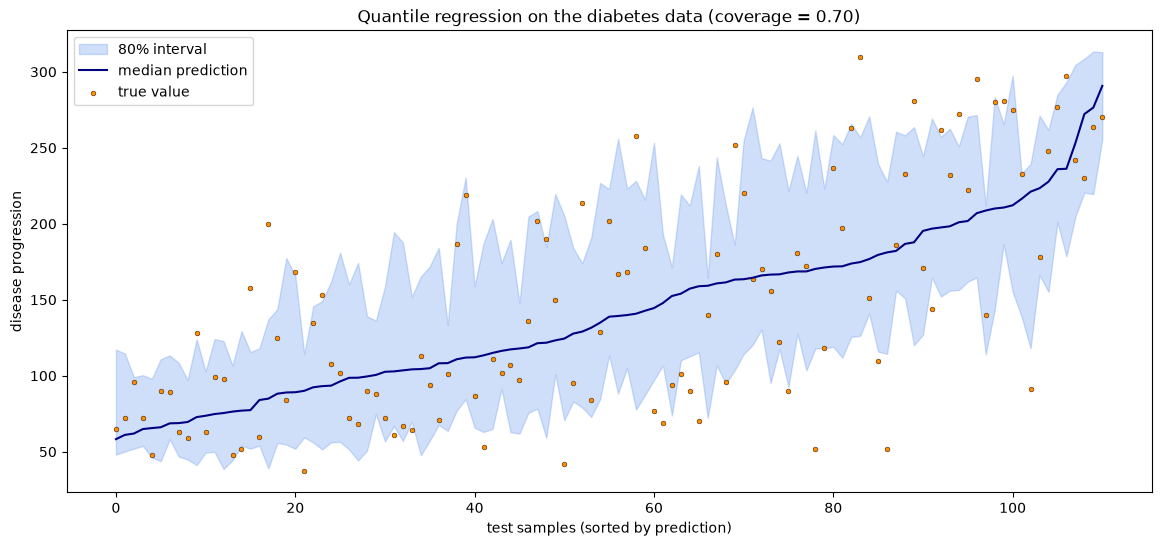

In [16]:
order = np.argsort(median)

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(range(len(order)), lower[order], upper[order],
                alpha=0.3, color="cornflowerblue", label="80% interval")
ax.plot(median[order], color="navy", label="median prediction")
ax.scatter(range(len(order)), y_test.to_numpy()[order], s=12, c="darkorange",
           edgecolor="black", linewidths=0.3, label="true value")
ax.set(title=f"Quantile regression on the diabetes data (coverage = {coverage:.2f})",
       xlabel="test samples (sorted by prediction)", ylabel="disease progression")
ax.legend()
fig.show()

Note that the intervals are **not** equally wide everywhere — the model has learned that some patients are harder to predict than others. That adaptivity is the main advantage of quantile regression, and we want to keep it. We only want to fix the coverage.

Exactly that is what conformal prediction does, and it is the topic of the next notebook.

---

Lecture: AI I - Basics 

Exercise: [**Exercise 4.4: Gradinat Boosting**]()

Next: [**Chapter 4.5: Conformal methods**](./04_gradiant_boosting.ipynb)